In [9]:
# For data storage and manipulation
import pandas as pd
# for numeric computations
import numpy as np

In [10]:
# for diagramming 
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# for ML methods and algorithms
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import sklearn.metrics as sm

In [12]:
# for serialization and deserialization of data from and to a file
import pickle

## Step 2: Data Preparation

### 2.1 Read and Get to Know the Data

In [13]:
# read the data
df = pd.read_csv("Data/WA_Fn-UseC_-HR-Employee-Attrition.csv", sep = ',')

In [14]:
df.shape

(1470, 35)

In [15]:
# see which are the attribute labels
list(df)

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [18]:
# get idea of the look
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
670,27,No,Travel_Rarely,618,Research & Development,4,3,Life Sciences,1,933,...,3,80,0,1,2,3,1,1,0,0
1419,42,No,Travel_Rarely,557,Research & Development,18,4,Life Sciences,1,1998,...,3,80,1,9,3,2,4,3,1,2
285,37,No,Travel_Rarely,1372,Research & Development,1,3,Life Sciences,1,391,...,2,80,0,17,3,3,17,12,5,7
1383,36,No,Non-Travel,1351,Research & Development,9,4,Life Sciences,1,1949,...,2,80,0,5,3,3,5,4,0,2
233,50,No,Travel_Rarely,854,Sales,1,4,Medical,1,323,...,3,80,1,32,3,2,7,0,0,6


### 2.2 Visualise the Data

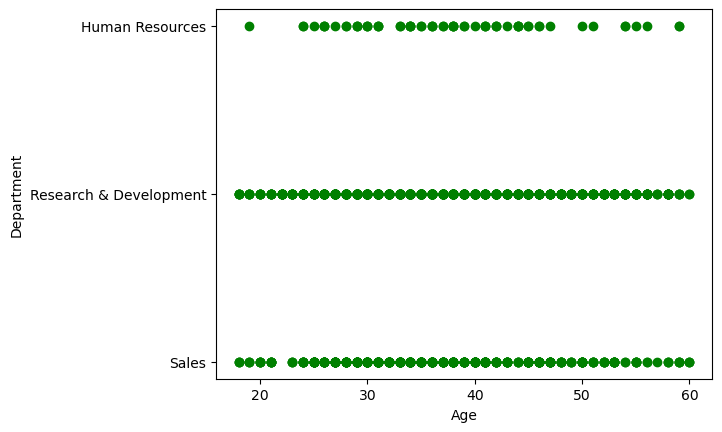

In [19]:
# skatter plot of all
plt.xlabel('Age')
plt.ylabel('Department')
plt.scatter(df.Age, df.Department, color='green')
plt.show()

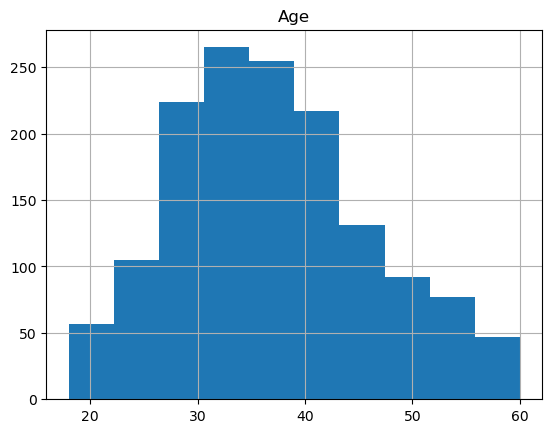

In [23]:
# histograms
hist = df.hist('Age')

### 2.3 Clean the Data

In [24]:
# to check null values in data
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Step 3. Explore the Descriptive Statistics of Data

In [25]:
# get idea of basic statistical parameters for each column
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


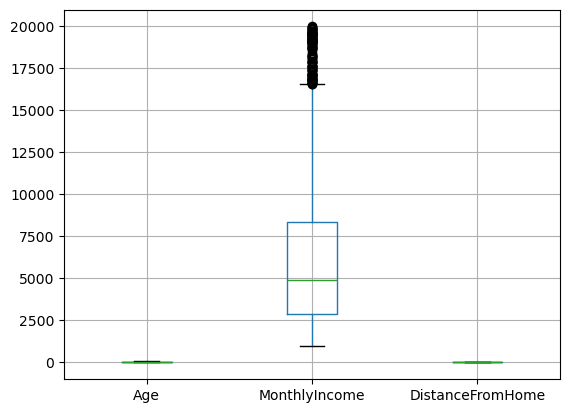

In [28]:
# box-wisker plot
boxplot = df.boxplot(column=["Age", "MonthlyIncome", "DistanceFromHome"])  


In [29]:
# outliers by interquartile range (IQR)
from typing import List
def remove_outliers(df, data: List):
    q1 = data.quantile(.25)
    q3 = data.quantile(.75)
    IQR = q3 - q1
    # values smaller than 1.5 IQR below q1 and bigger that 1.5 IQR over q3 
    outliers = df[(data < (q1 - 1.5 * IQR)) | (data > (q3 + 1.5 * IQR))]
    df = df.drop(outliers.index, inplace=True)
    return df

In [31]:
remove_outliers(df, df['MonthlyIncome'])

In [32]:
df.shape

(1356, 35)

In [34]:
# --- Regression: Predict MonthlyIncome ---

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Features (X) and target (y)
X = df.drop(["MonthlyIncome", "Attrition"], axis=1)   # remove target columns
y = df["MonthlyIncome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use dummy variables for categorical columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Make sure train and test have same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Train model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Metrics
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))  # manual RMSE
print("MAE:", mean_absolute_error(y_test, y_pred))



R2 Score: 0.8694792971810439
RMSE: 1242.837165871807
MAE: 937.224552424656
